In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter

In [2]:
df = pd.read_csv('/chatgpt_reviews.csv')

In [3]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [4]:
df['Review'] = df['Review'].fillna('')
df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')
df['Ratings'] = pd.to_numeric(df['Ratings'], errors='coerce')


In [5]:
df.isnull().sum()

,0
Review Id,0
Review,0
Ratings,0
Review Date,0


In [7]:
#Sentiment Analysis
#classifying review into +ve/-ve and neutral

In [10]:
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Review'].apply(get_sentiment)
display(df.head())
display(df['Sentiment'].value_counts())

,Review Id,Review,Ratings,Review Date,Sentiment
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,Positive
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,Positive
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,Positive
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,Positive
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,Positive


,count
Sentiment,
Positive,150122
Neutral,38450
Negative,8155


## Visualize sentiment over time

### Subtask:
Create a line plot to show the trend of each sentiment category over time.

**Reasoning**:
Create a line plot to visualize the trend of each sentiment category over time using Altair.

In [17]:
import altair as alt

chart = alt.Chart(sentiment_over_time).mark_line().encode(
    x=alt.X('YearMonth', title='Time'),
    y=alt.Y('count', title='Number of Reviews'),
    color='Sentiment',
    tooltip=['YearMonth', 'Sentiment', 'count']
).properties(
    title='Sentiment Over Time'
).interactive()

chart.save('sentiment_over_time_line_plot.json')
display(chart)

alt.Chart(...)

In [22]:
# Identify in each bucket how many common words or phrases are there
# trend over time- count of reviews(positive, negative or neutral)
# correlation between ratings and time

## Analyze Ratings

### Subtask:
Calculate the average rating and visualize the distribution of ratings.

**Reasoning**:
Calculate the mean of the 'Ratings' column to find the average rating.

In [21]:
average_rating = df['Ratings'].mean()
print(f"The average rating of ChatGPT is: {average_rating:.2f}")

The average rating of ChatGPT is: 4.50


**Reasoning**:
Create a histogram to visualize the distribution of ratings.

/tmp/ipython-input-28609095.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Ratings', data=df, palette='viridis')


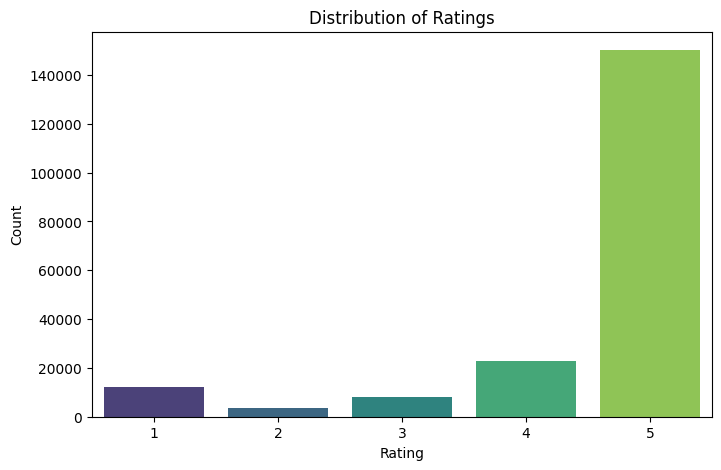

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Ratings', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Task
Analyze the most common words or topics in the reviews.

## Text cleaning

### Subtask:
Preprocess the 'Review' text data by removing punctuation, converting to lowercase, and removing common English stop words.


**Reasoning**:
Preprocess the 'Review' text data by removing punctuation, converting to lowercase, and removing common English stop words.



In [23]:
import string
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.lower()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['cleaned_review'] = df['Review'].apply(clean_text)
display(df[['Review', 'cleaned_review']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Review,cleaned_review
0,good,good
1,good,good
2,nice app,nice app
3,"nice, ig",nice ig
4,"this is a great app, the bot is so accurate to...",great app bot accurate anything gives tips gam...


## Tokenization

### Subtask:
Split the cleaned text into individual words (tokens).


**Reasoning**:
Create a new column 'tokens' by splitting the 'cleaned_review' text into individual words.



In [24]:
df['tokens'] = df['cleaned_review'].apply(lambda x: x.split())
display(df[['cleaned_review', 'tokens']].head())

,cleaned_review,tokens
0,good,[good]
1,good,[good]
2,nice app,"[nice, app]"
3,nice ig,"[nice, ig]"
4,great app bot accurate anything gives tips gam...,"[great, app, bot, accurate, anything, gives, t..."


## Word frequency analysis

### Subtask:
Count the occurrences of each word to find the most common ones.


**Reasoning**:
Count the occurrences of each word in the tokens column using Counter.



In [25]:
all_tokens = [token for tokens_list in df['tokens'] for token in tokens_list]
word_counts = Counter(all_tokens)
display(word_counts.most_common(10))

[('app', 49954),
 ('good', 39320),
 ('best', 18322),
 ('nice', 13711),
 ('great', 11926),
 ('ai', 11868),
 ('helpful', 11591),
 ('chatgpt', 10045),
 ('like', 9044),
 ('love', 8644)]

## Visualize most common words

### Subtask:
Create a visualization (e.g., a bar chart or word cloud) to display the most frequent words.


**Reasoning**:
Extract the top N most common words, create a DataFrame, and visualize the word frequencies using a bar chart.



/tmp/ipython-input-566917628.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


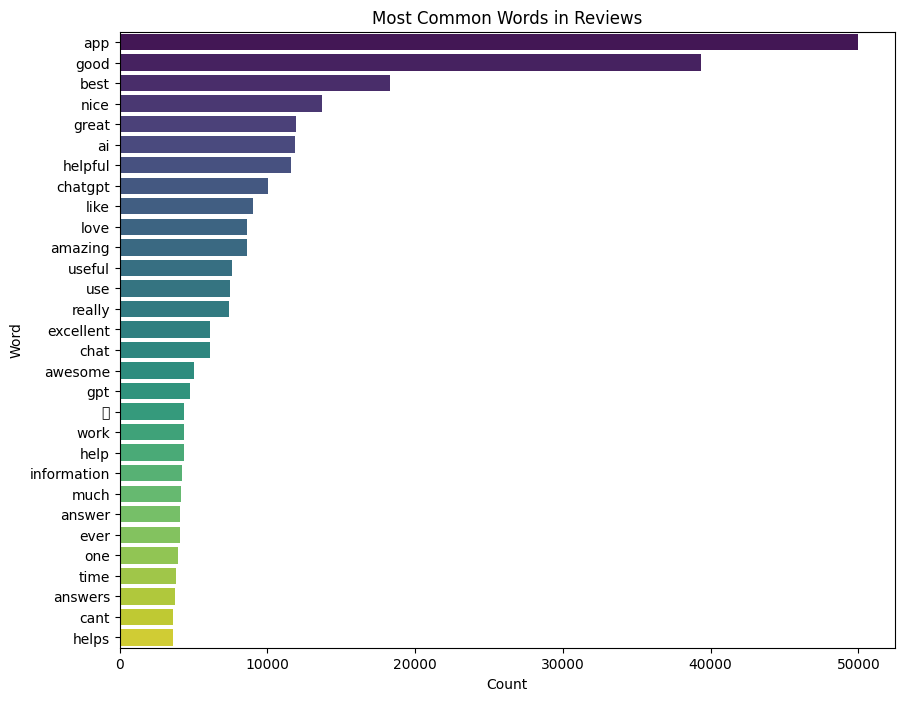

In [26]:
N = 30
top_words = word_counts.most_common(N)
top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(10, 8))
sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')
plt.title('Most Common Words in Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The top 10 most common words in the reviews are: 'app', 'good', 'best', 'nice', 'great', 'ai', 'helpful', 'chatgpt', 'like', and 'love'.
*   A bar chart visualizing the frequency of the top 30 most common words was generated.

### Insights or Next Steps

*   Consider performing N-gram analysis to identify common phrases or multi-word topics in the reviews.
*   Explore sentiment analysis on the reviews to understand the overall sentiment associated with the most common words or topics.


# Task
Analyze the correlation between common words and sentiment in the reviews.

## Prepare data for sentiment-word analysis

### Subtask:
Ensure the 'cleaned_review' and 'Sentiment' columns are available and ready for analysis.


**Reasoning**:
Verify that the DataFrame `df` contains the columns 'cleaned_review' and 'Sentiment' and display the first few rows to confirm their presence and content.



In [27]:
print(df.columns)
display(df[['cleaned_review', 'Sentiment']].head())

Index(['Review Id', 'Review', 'Ratings', 'Review Date', 'Sentiment',
       'YearMonth', 'cleaned_review', 'tokens'],
      dtype='object')


,cleaned_review,Sentiment
0,good,Positive
1,good,Positive
2,nice app,Positive
3,nice ig,Positive
4,great app bot accurate anything gives tips gam...,Positive


## Analyze word frequency by sentiment

### Subtask:
Count the occurrences of each word within each sentiment category (Positive, Negative, Neutral).


**Reasoning**:
Count the occurrences of each word within each sentiment category.



In [28]:
sentiment_word_counts = {}

for sentiment in df['Sentiment'].unique():
    sentiment_df = df[df['Sentiment'] == sentiment]
    all_tokens_sentiment = [token for tokens_list in sentiment_df['tokens'] for token in tokens_list]
    sentiment_word_counts[sentiment] = Counter(all_tokens_sentiment)

for sentiment, counts in sentiment_word_counts.items():
    print(f"Most common words in {sentiment} reviews:")
    display(counts.most_common(10))

Most common words in Positive reviews:


[('app', 43603),
 ('good', 38929),
 ('best', 18291),
 ('nice', 13671),
 ('great', 11860),
 ('ai', 10186),
 ('helpful', 9637),
 ('amazing', 8595),
 ('love', 8545),
 ('chatgpt', 8124)]

Most common words in Negative reviews:


[('app', 2389),
 ('wrong', 856),
 ('bad', 853),
 ('chatgpt', 761),
 ('cant', 694),
 ('ai', 671),
 ('like', 647),
 ('use', 641),
 ('time', 604),
 ('even', 585)]

Most common words in Neutral reviews:


[('app', 3962),
 ('helpful', 1716),
 ('like', 1592),
 ('chatgpt', 1160),
 ('ai', 1011),
 ('cant', 991),
 ('chat', 797),
 ('👍', 796),
 ('helps', 729),
 ('thank', 721)]

## Identify common words for each sentiment

### Subtask:
Determine the most frequent words for each sentiment category.


**Reasoning**:
Extract the top N most common words for each sentiment category and store them.



In [29]:
N = 30  # Choose a reasonable number for N

top_words_by_sentiment = {}

for sentiment, counts in sentiment_word_counts.items():
    top_words_by_sentiment[sentiment] = counts.most_common(N)

for sentiment, top_words in top_words_by_sentiment.items():
    print(f"Top {N} words in {sentiment} reviews:")
    display(top_words)

Top 30 words in Positive reviews:


[('app', 43603),
 ('good', 38929),
 ('best', 18291),
 ('nice', 13671),
 ('great', 11860),
 ('ai', 10186),
 ('helpful', 9637),
 ('amazing', 8595),
 ('love', 8545),
 ('chatgpt', 8124),
 ('useful', 7481),
 ('really', 7090),
 ('like', 6805),
 ('use', 6157),
 ('excellent', 6108),
 ('awesome', 5017),
 ('chat', 4759),
 ('much', 3946),
 ('ever', 3769),
 ('gpt', 3662),
 ('👍', 3544),
 ('help', 3469),
 ('information', 3432),
 ('better', 3352),
 ('one', 3337),
 ('work', 3322),
 ('answer', 3015),
 ('answers', 3015),
 ('application', 2937),
 ('questions', 2831)]

Top 30 words in Negative reviews:


[('app', 2389),
 ('wrong', 856),
 ('bad', 853),
 ('chatgpt', 761),
 ('cant', 694),
 ('ai', 671),
 ('like', 647),
 ('use', 641),
 ('time', 604),
 ('even', 585),
 ('answer', 560),
 ('chat', 549),
 ('dont', 511),
 ('im', 443),
 ('information', 435),
 ('doesnt', 432),
 ('please', 431),
 ('give', 405),
 ('answers', 402),
 ('good', 385),
 ('gpt', 371),
 ('get', 354),
 ('worst', 351),
 ('work', 345),
 ('voice', 345),
 ('sometimes', 338),
 ('one', 327),
 ('also', 319),
 ('useless', 315),
 ('using', 311)]

Top 30 words in Neutral reviews:


[('app', 3962),
 ('helpful', 1716),
 ('like', 1592),
 ('chatgpt', 1160),
 ('ai', 1011),
 ('cant', 991),
 ('chat', 797),
 ('👍', 796),
 ('helps', 729),
 ('thank', 721),
 ('gpt', 720),
 ('please', 688),
 ('work', 686),
 ('help', 649),
 ('use', 644),
 ('working', 611),
 ('hai', 606),
 ('lot', 590),
 ('doesnt', 584),
 ('dont', 554),
 ('need', 543),
 ('life', 503),
 ('answer', 497),
 ('well', 459),
 ('voice', 451),
 ('error', 445),
 ('login', 435),
 ('give', 435),
 ('update', 398),
 ('time', 391)]

## Visualize sentiment-specific common words

### Subtask:
Create visualizations (e.g., bar charts or word clouds for each sentiment) to display the most frequent words associated with each sentiment.


**Reasoning**:
Iterate through the top_words_by_sentiment dictionary, create a DataFrame for each sentiment's top words, and generate bar plots to visualize the most frequent words for each sentiment.



/tmp/ipython-input-1305484471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


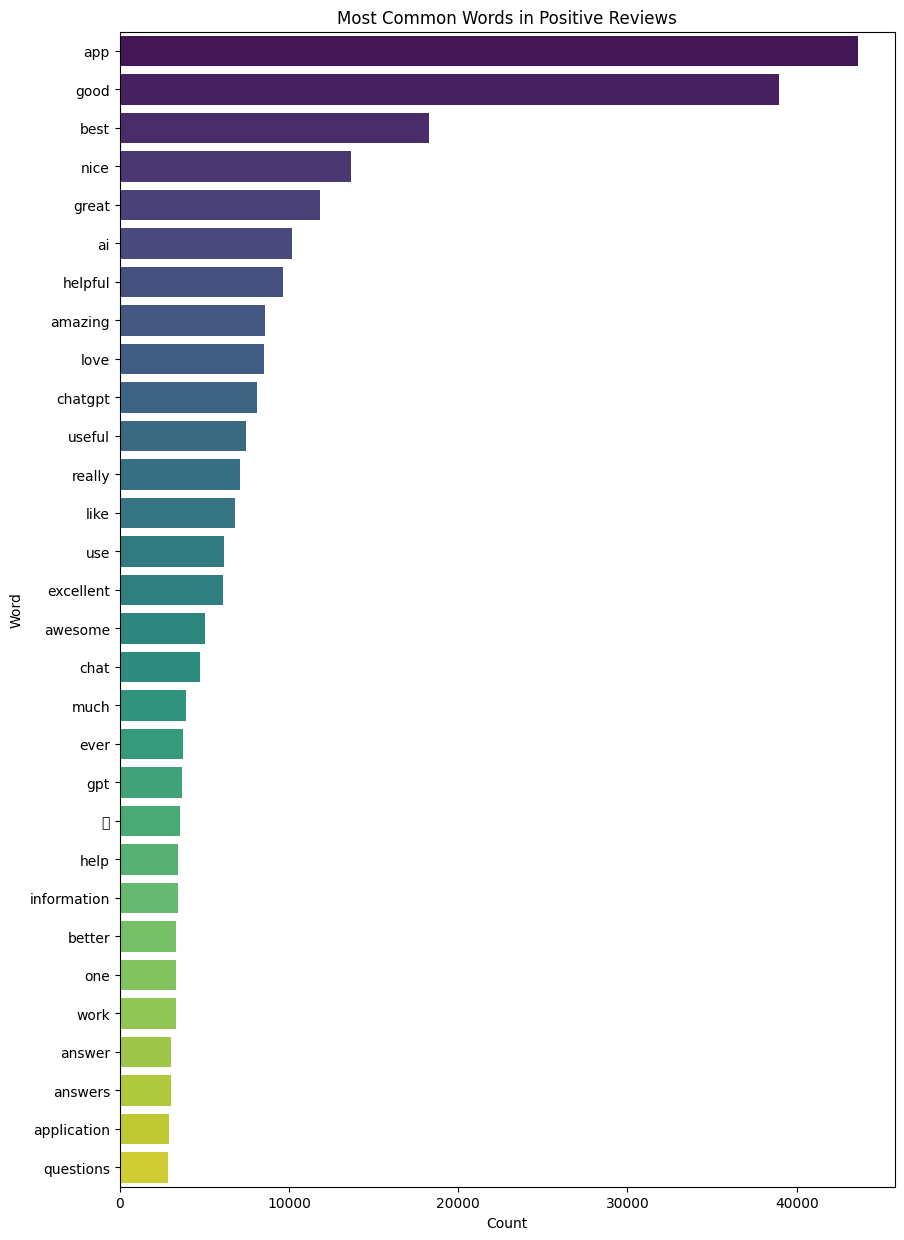

/tmp/ipython-input-1305484471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')


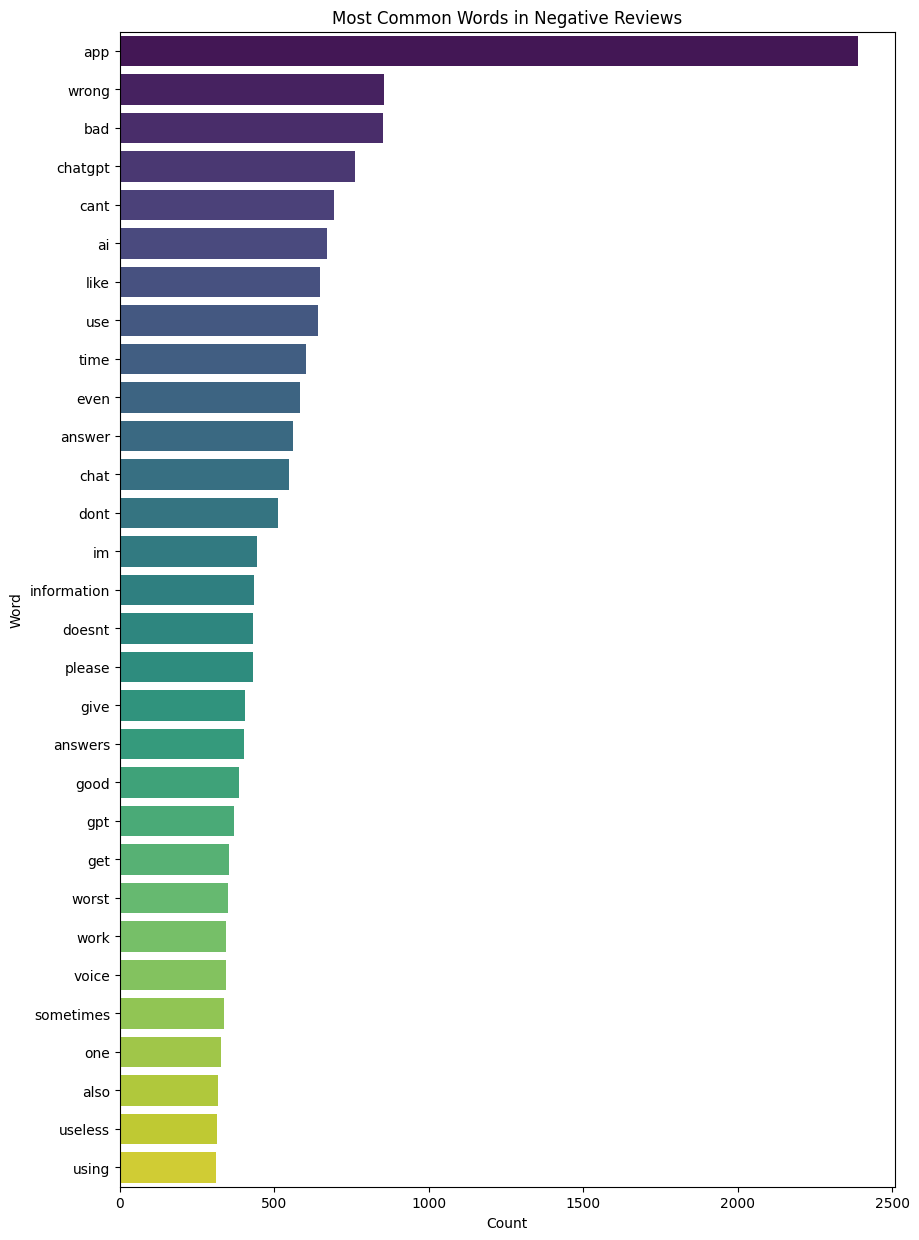

/tmp/ipython-input-1305484471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


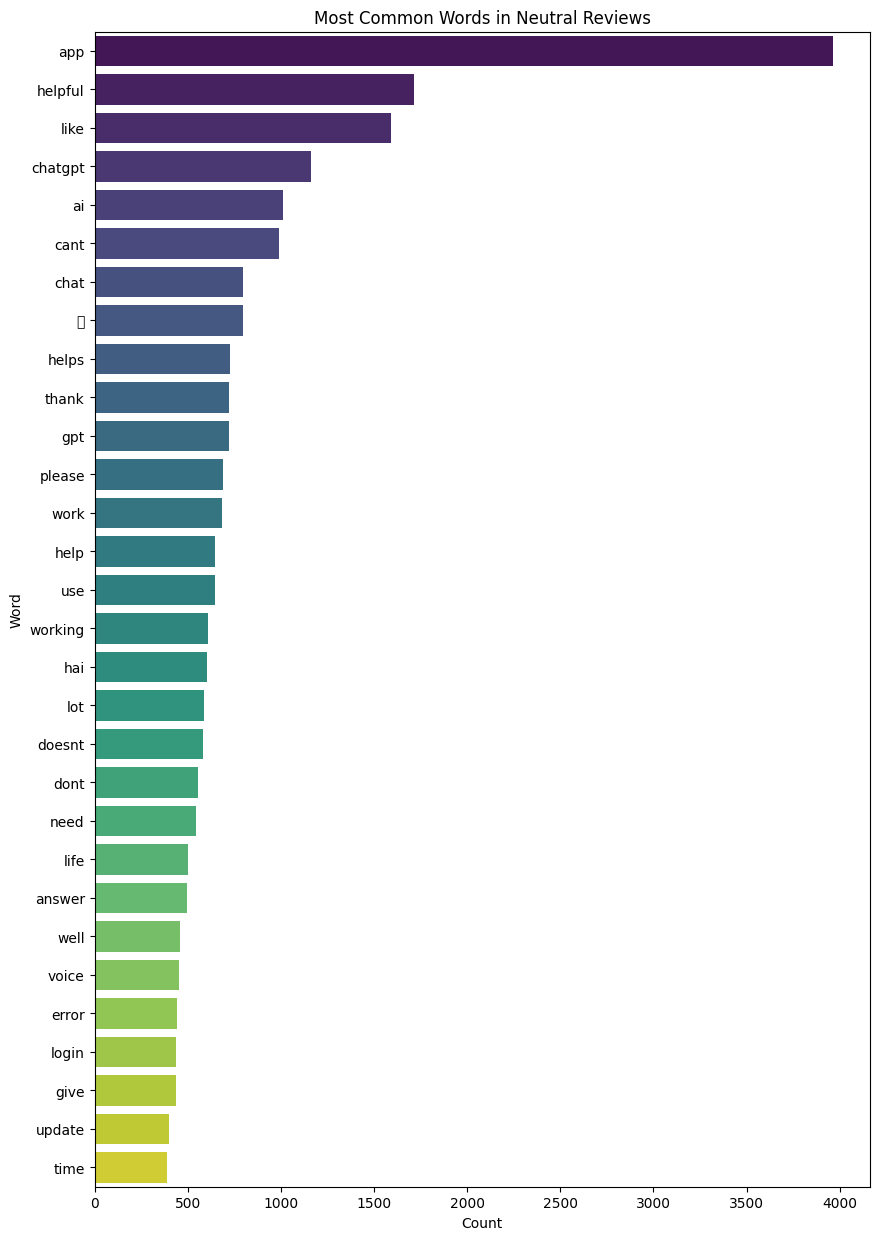

In [30]:
for sentiment, top_words in top_words_by_sentiment.items():
    top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])

    plt.figure(figsize=(10, min(len(top_words) * 0.5, 15))) # Adjust figure size based on number of words
    sns.barplot(x='count', y='word', data=top_words_df, palette='viridis')
    plt.title(f'Most Common Words in {sentiment} Reviews')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.show()

## Summary:

### Data Analysis Key Findings

*   The DataFrame contains both 'cleaned\_review' and 'Sentiment' columns, confirming their availability for analysis.
*   Word occurrences were counted for each sentiment category (Positive, Negative, and Neutral).
*   The top 30 most common words were identified for each sentiment.
*   Certain words like "app," "chatgpt," and "ai" are frequent across all sentiments.
*   Words like "good," "best," "great," and "love" are highly frequent in Positive reviews.
*   Words like "wrong," "bad," and "cant" are frequent in Negative reviews.
*   Words like "helpful," "helps," and "thank" are frequent in Neutral reviews.
*   Bar charts visualizing the most common words in positive, negative, and neutral reviews were successfully generated.

### Insights or Next Steps

*   The analysis reveals distinct vocabularies associated with different sentiment categories, providing insights into the specific aspects users mention when expressing positive, negative, or neutral opinions.
*   Further analysis could involve calculating the sentiment scores of individual words or phrases to quantify their association with different sentiments.


# Task
Analyze the correlation between rating and time.

## Prepare data for time series analysis

### Subtask:
Ensure the 'Review Date' and 'Ratings' columns are ready for analysis.


**Reasoning**:
Verify that the DataFrame df contains the columns 'Review Date' and 'Ratings' and display the first few rows to confirm their presence and content.



In [31]:
print(df.columns)
display(df[['Review Date', 'Ratings']].head())

Index(['Review Id', 'Review', 'Ratings', 'Review Date', 'Sentiment',
       'YearMonth', 'cleaned_review', 'tokens'],
      dtype='object')


,Review Date,Ratings
0,2024-08-23 19:30:05,5
1,2024-08-23 19:28:18,5
2,2024-08-23 19:22:59,5
3,2024-08-23 19:20:50,5
4,2024-08-23 19:20:39,5


## Group data by time and calculate average rating

### Subtask:
Group the data by a suitable time period (e.g., month or year) and calculate the average rating for each period.


**Reasoning**:
Group the data by year and month and calculate the average rating for each period.



In [32]:
df['YearMonth'] = df['Review Date'].dt.to_period('M')
average_rating_over_time = df.groupby('YearMonth')['Ratings'].mean().reset_index()
display(average_rating_over_time.head())
display(average_rating_over_time.columns)

,YearMonth,Ratings
0,2023-07,4.439454
1,2023-08,4.327746
2,2023-09,4.494534
3,2023-10,4.525755
4,2023-11,4.523913


Index(['YearMonth', 'Ratings'], dtype='object')

## Visualize average rating over time

### Subtask:
Create a line plot to show the trend of the average rating over time.


**Reasoning**:
Create a line plot to visualize the trend of the average rating over time.



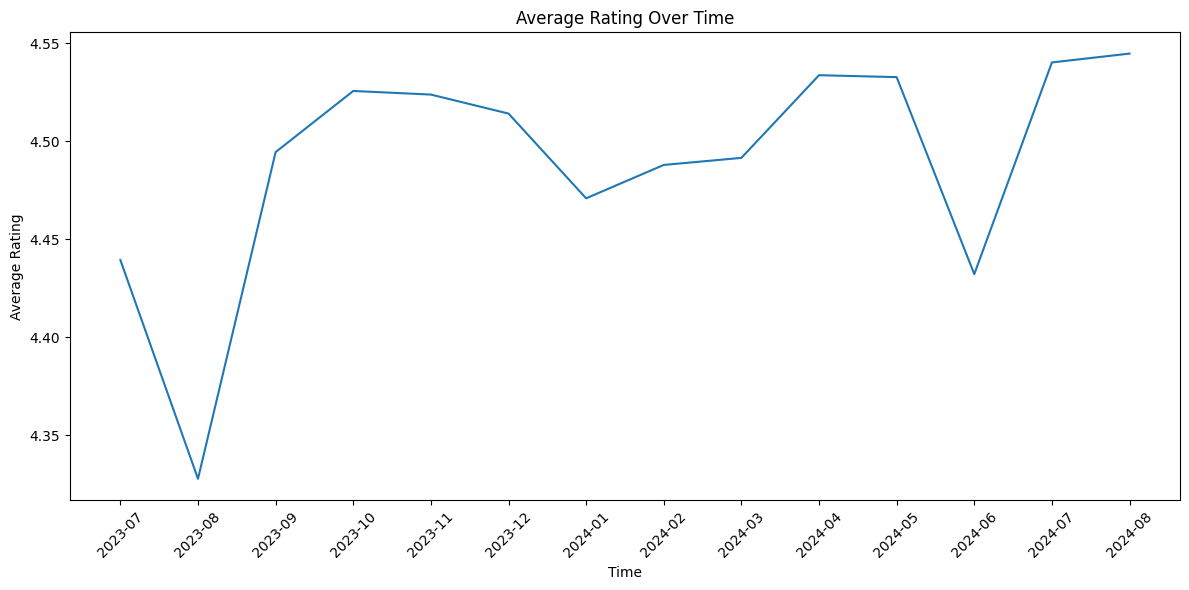

In [33]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=average_rating_over_time['YearMonth'].astype(str), y='Ratings', data=average_rating_over_time)
plt.title('Average Rating Over Time')
plt.xlabel('Time')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The average rating over time was calculated by grouping the data by month and year.
*   A line plot was generated to visualize the trend of the average rating over time.

### Insights or Next Steps

*   The visualization of the average rating over time can help identify any noticeable trends or patterns in customer sentiment.
*   Further analysis could involve correlating the average rating trend with external factors or events that might have influenced customer reviews.
